# Analisis Komparatif Hyperparameter Optimization pada Object Detection

Notebook ini mengagregasi dan memvisualisasikan hasil eksperimen dari **6 arsitektur model** yang dioptimasi menggunakan **4 algoritma metaheuristik** dengan evaluasi **5-Fold Cross Validation**.

**Cakupan Analisis:**
1. Pemuatan data metrik evaluasi riil dari seluruh model
2. Tabel ringkasan performa rata-rata
3. Grafik perbandingan mAP50 dan multi-metrik
4. Analisis peningkatan relatif (delta) terhadap Baseline
5. Heatmap perbandingan multi-metrik
6. Radar chart profil performa tiap model
7. Scatter plot trade-off Precision vs Recall
8. Tabel hyperparameter terbaik
9. Identifikasi kombinasi model-optimizer terbaik
10. Ranking global dan ringkasan temuan

In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

print('Library berhasil diimpor.')

Library berhasil diimpor.


## 1. Konfigurasi Model dan Direktori Hasil

Setiap model memiliki file `final_metrics_comparison.csv` di direktori hasil masing-masing.

In [16]:
models = ['yolov8n', 'yolov9t', 'yolov10n', 'yolo11n', 'yolo26n', 'rtdetr-l']

model_dirs = {
    'yolov8n': '../../results/yolov8',
    'yolov9t': '../../results/yolov9',
    'yolov10n': '../../results/yolov10',
    'yolo11n': '../../results/yolov11',
    'yolo26n': '../../results/yolov26',
    'rtdetr-l': '../../results/rtdetr'
}

print('Daftar model dan direktori hasil:')
for k, v in model_dirs.items():
    csv_path = os.path.join(v, 'final_metrics_comparison.csv')
    status = 'OK' if os.path.exists(csv_path) else 'NOT FOUND'
    print(f'  [{status}] {k.upper():12s} -> {csv_path}')

Daftar model dan direktori hasil:
  [OK] YOLOV8N      -> ../../results/yolov8/final_metrics_comparison.csv
  [OK] YOLOV9T      -> ../../results/yolov9/final_metrics_comparison.csv
  [OK] YOLOV10N     -> ../../results/yolov10/final_metrics_comparison.csv
  [OK] YOLO11N      -> ../../results/yolov11/final_metrics_comparison.csv
  [OK] YOLO26N      -> ../../results/yolov26/final_metrics_comparison.csv
  [OK] RTDETR-L     -> ../../results/rtdetr/final_metrics_comparison.csv


## 2. Pemuatan dan Penggabungan Data Metrik Riil

Data dimuat langsung dari file CSV hasil training tanpa simulasi atau data tiruan.

In [17]:
all_dfs = []
for m in models:
    csv_path = os.path.join(model_dirs[m], 'final_metrics_comparison.csv')
    df = pd.read_csv(csv_path)
    if 'Optimizer' in df.columns:
        df = df.rename(columns={'Optimizer': 'Method'})
    df['Model'] = m.upper()
    all_dfs.append(df)

df_summary = pd.concat(all_dfs, ignore_index=True)
print(f'Total {len(df_summary)} baris data dari {len(models)} model berhasil dimuat.')
print(f'Metode: {df_summary["Method"].unique().tolist()}')

Total 30 baris data dari 6 model berhasil dimuat.
Metode: ['Baseline', 'PSO', 'GWO', 'WOA', 'ACO']


## 3. Tabel Ringkasan Performa Seluruh Model

Rata-rata Precision, Recall, mAP50, dan mAP50-95 dari evaluasi 5-Fold Cross Validation.

In [18]:
metric_cols = ['Precision', 'Recall', 'mAP50', 'mAP50-95']
display_cols = ['Model', 'Method'] + metric_cols
df_display = df_summary[display_cols].copy()
for col in metric_cols:
    df_display[col] = df_display[col].map(lambda x: f'{x:.4f}')
df_summary[display_cols].to_csv('aggregated_models_summary.csv', index=False)
print('Tabel ringkasan disimpan ke aggregated_models_summary.csv')
df_display

Tabel ringkasan disimpan ke aggregated_models_summary.csv


,Model,Method,Precision,Recall,mAP50,mAP50-95
0,YOLOV8N,Baseline,0.8510,0.8504,0.8962,0.7800
1,YOLOV8N,PSO,0.8473,0.8462,0.8937,0.7725
2,YOLOV8N,GWO,0.8750,0.8060,0.8906,0.7750
3,YOLOV8N,WOA,0.8474,0.8236,0.8831,0.7509
4,YOLOV8N,ACO,0.8649,0.8358,0.8929,0.7689
5,YOLOV9T,Baseline,0.8266,0.8450,0.8890,0.7912
6,YOLOV9T,PSO,0.8707,0.8154,0.8938,0.7936
7,YOLOV9T,GWO,0.8590,0.8306,0.8964,0.7901
8,YOLOV9T,WOA,0.8675,0.8335,0.8971,0.8000
9,YOLOV9T,ACO,0.8395,0.8685,0.9038,0.8050


## 4. Perbandingan Kinerja mAP50 Baseline vs HPO

Grafik batang perbandingan mAP50 rata-rata antara Baseline dan hasil optimasi HPO.

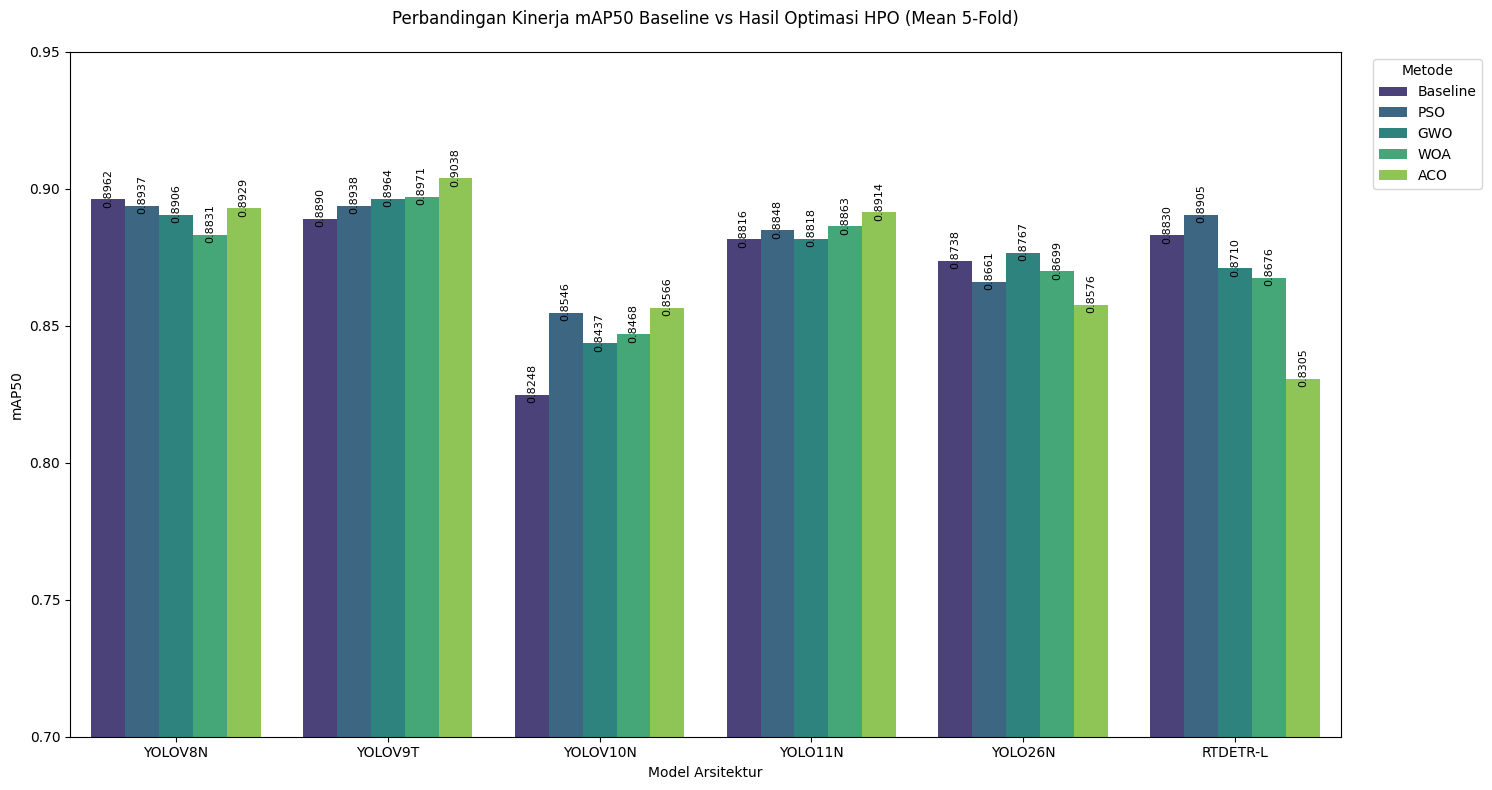

In [19]:
plt.figure(figsize=(15, 8))
ax = sns.barplot(x='Model', y='mAP50', hue='Method', data=df_summary, palette='viridis')
plt.title('Perbandingan Kinerja mAP50 Baseline vs Hasil Optimasi HPO (Mean 5-Fold)', pad=20)
plt.xlabel('Model Arsitektur')
plt.ylabel('mAP50')
plt.ylim(0.70, 0.95)
plt.legend(title='Metode', bbox_to_anchor=(1.02, 1), loc='upper left')
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=8, rotation=90)
plt.tight_layout()
plt.savefig('comparison_map50_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Perbandingan Multi-Metrik (Grouped Bar Chart)

Perbandingan seluruh metrik evaluasi (Precision, Recall, mAP50, mAP50-95) dalam satu figure.

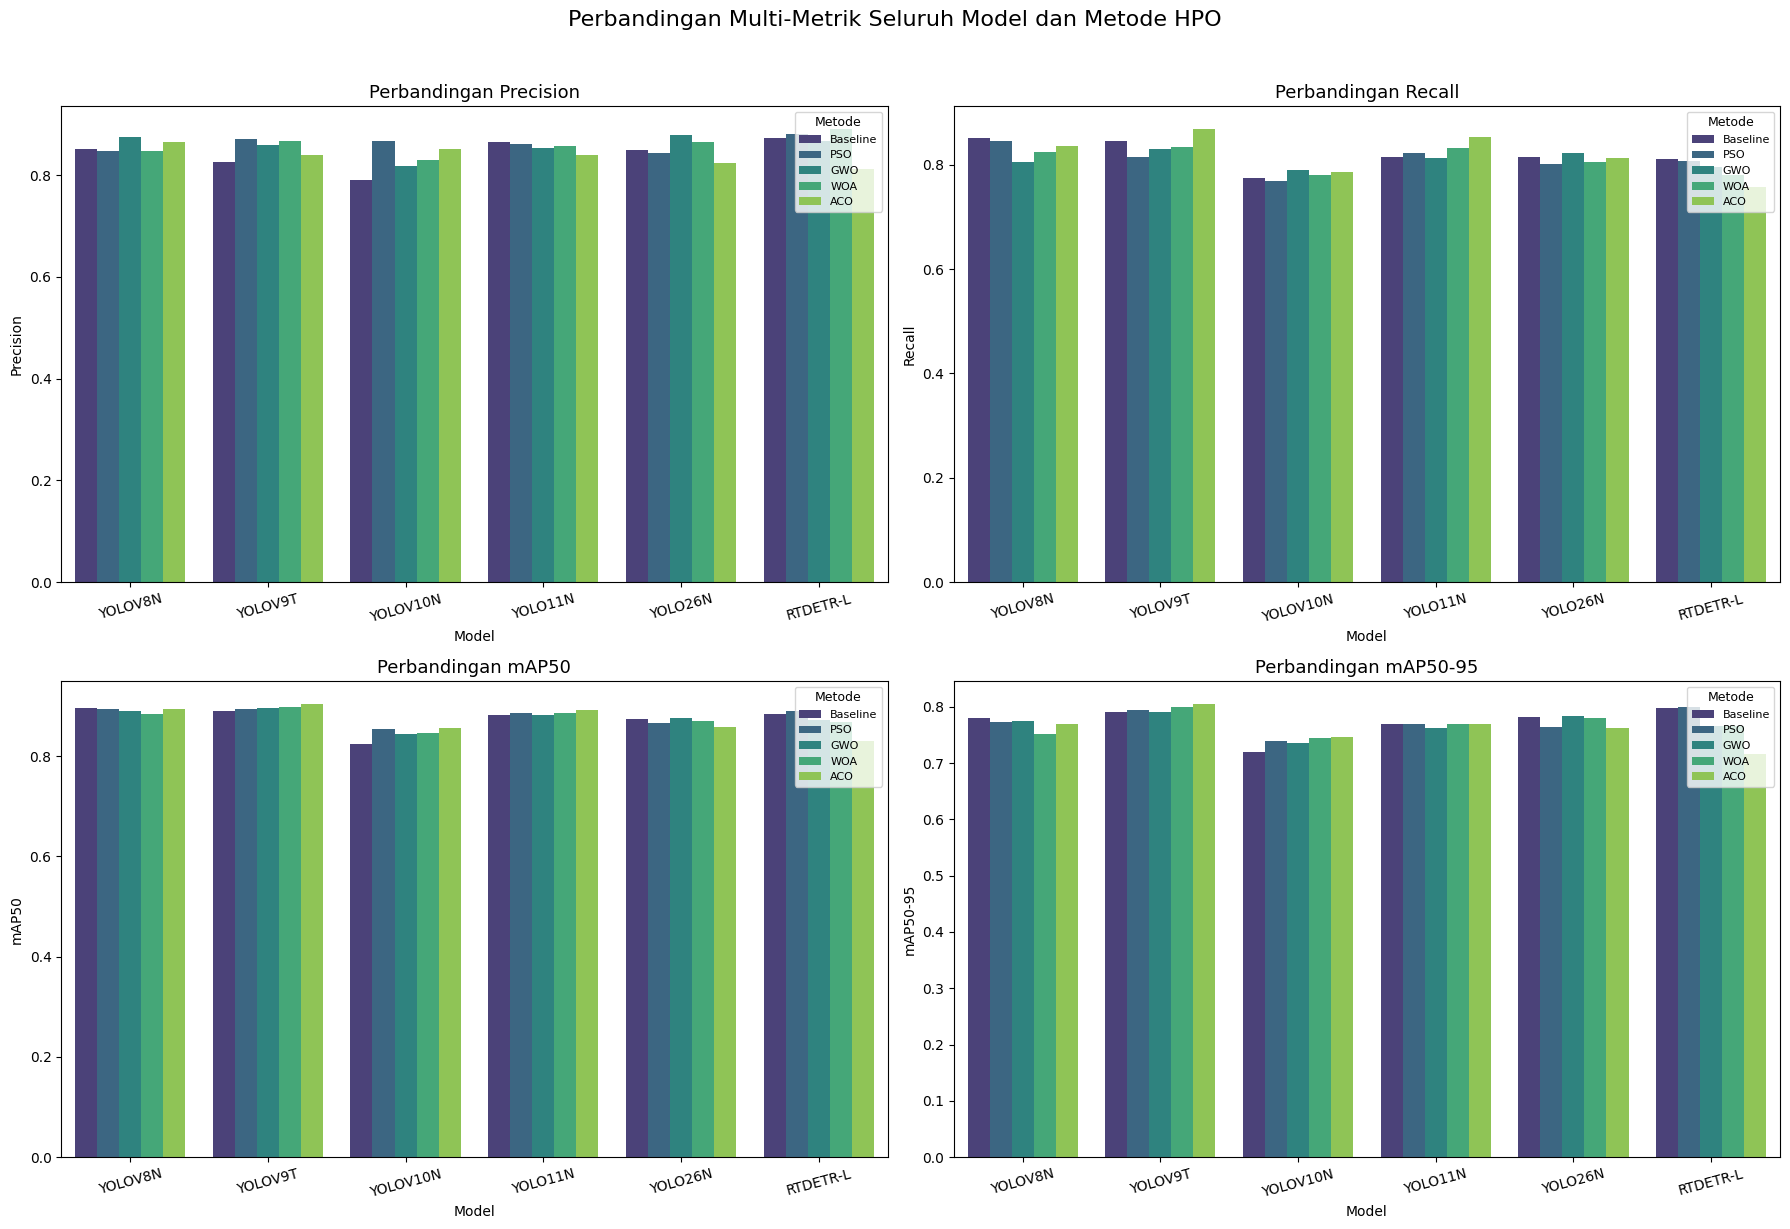

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, metric in zip(axes.flatten(), ['Precision', 'Recall', 'mAP50', 'mAP50-95']):
    sns.barplot(x='Model', y=metric, hue='Method', data=df_summary, palette='viridis', ax=ax)
    ax.set_title(f'Perbandingan {metric}', fontsize=13)
    ax.set_xlabel('Model')
    ax.set_ylabel(metric)
    ax.legend(title='Metode', fontsize=8, title_fontsize=9)
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('Perbandingan Multi-Metrik Seluruh Model dan Metode HPO', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('comparison_multi_metric_bar.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Analisis Peningkatan Relatif (Delta) terhadap Baseline

Selisih mAP50 setiap metode HPO terhadap Baseline dalam satuan absolut dan persentase.

In [21]:
delta_rows = []
for m in models:
    md_ = df_summary[df_summary['Model'] == m.upper()]
    bl = md_[md_['Method'] == 'Baseline']['mAP50'].values[0]
    for _, row in md_.iterrows():
        if row['Method'] == 'Baseline': continue
        d = row['mAP50'] - bl
        delta_rows.append({'Model': m.upper(), 'Method': row['Method'],
            'Baseline_mAP50': round(bl, 4), 'HPO_mAP50': round(row['mAP50'], 4),
            'Delta': round(d, 4), 'Delta_Pct': round((d/bl)*100, 2)})

df_delta = pd.DataFrame(delta_rows)
df_delta.to_csv('delta_analysis.csv', index=False)
print('Analisis delta disimpan ke delta_analysis.csv')
df_dd = df_delta.copy()
df_dd['Delta'] = df_dd['Delta'].map(lambda x: f'{x:+.4f}')
df_dd['Delta_Pct'] = df_dd['Delta_Pct'].map(lambda x: f'{x:+.2f}%')
df_dd

Analisis delta disimpan ke delta_analysis.csv


,Model,Method,Baseline_mAP50,HPO_mAP50,Delta,Delta_Pct
0,YOLOV8N,PSO,0.8962,0.8937,-0.0025,-0.27%
1,YOLOV8N,GWO,0.8962,0.8906,-0.0056,-0.63%
2,YOLOV8N,WOA,0.8962,0.8831,-0.0131,-1.46%
3,YOLOV8N,ACO,0.8962,0.8929,-0.0033,-0.37%
4,YOLOV9T,PSO,0.8890,0.8938,+0.0048,+0.55%
5,YOLOV9T,GWO,0.8890,0.8964,+0.0074,+0.83%
6,YOLOV9T,WOA,0.8890,0.8971,+0.0081,+0.91%
7,YOLOV9T,ACO,0.8890,0.9038,+0.0148,+1.66%
8,YOLOV10N,PSO,0.8248,0.8546,+0.0298,+3.62%
9,YOLOV10N,GWO,0.8248,0.8437,+0.0189,+2.29%


## 7. Heatmap Peningkatan mAP50 terhadap Baseline

Identifikasi visual kombinasi model-optimizer dengan peningkatan terbesar.

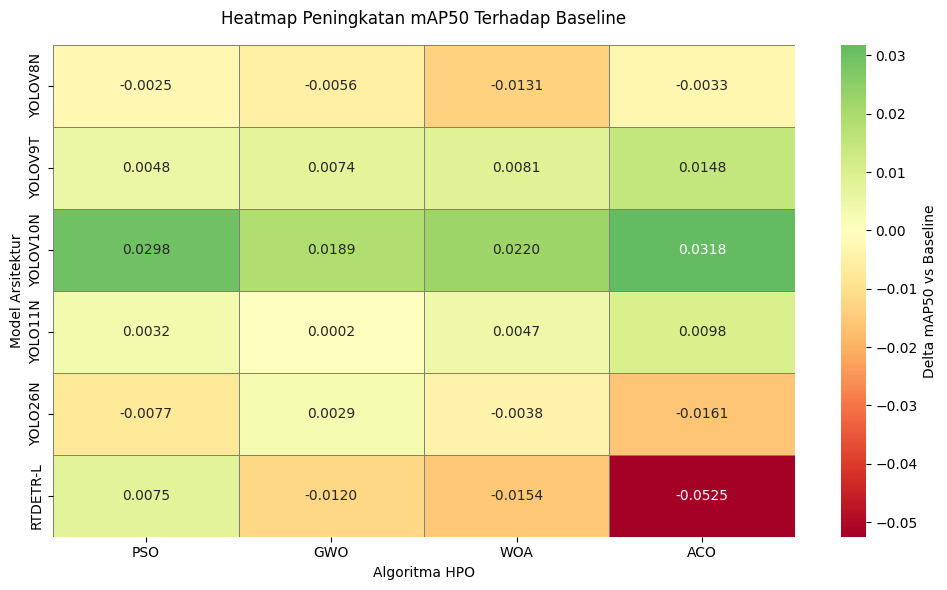

In [22]:
pivot_delta = df_delta.pivot(index='Model', columns='Method', values='Delta')
model_order = [m.upper() for m in models]
pivot_delta = pivot_delta.reindex(model_order)[['PSO', 'GWO', 'WOA', 'ACO']]

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_delta, annot=True, fmt='.4f', cmap='RdYlGn', center=0,
            linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Delta mAP50 vs Baseline'})
plt.title('Heatmap Peningkatan mAP50 Terhadap Baseline', pad=15)
plt.xlabel('Algoritma HPO')
plt.ylabel('Model Arsitektur')
plt.tight_layout()
plt.savefig('heatmap_delta_map50.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Heatmap Multi-Metrik

Perbandingan visual seluruh metrik evaluasi untuk setiap kombinasi model dan metode.

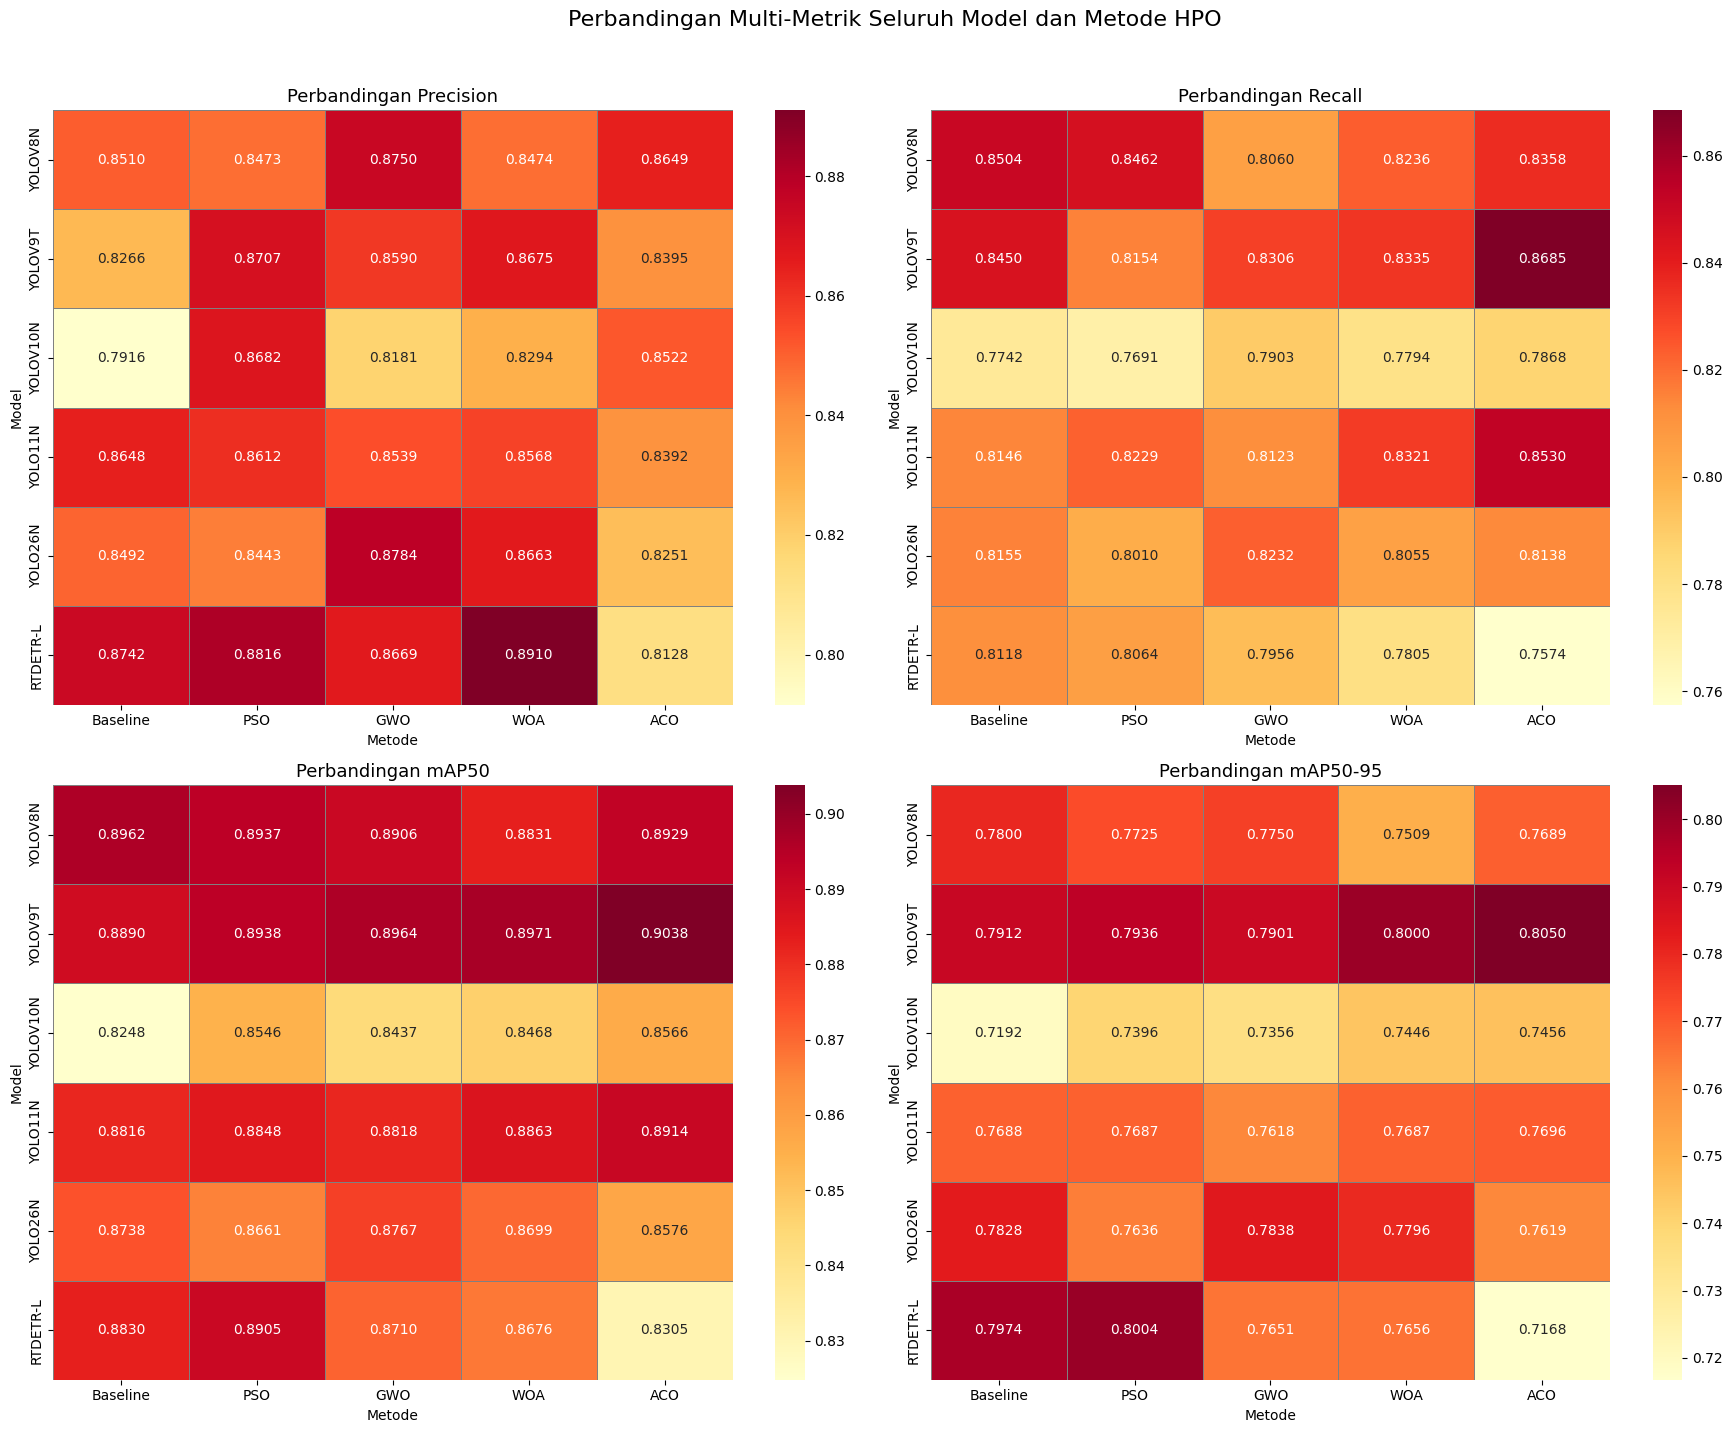

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
for ax, metric in zip(axes.flatten(), ['Precision', 'Recall', 'mAP50', 'mAP50-95']):
    pivot = df_summary.pivot(index='Model', columns='Method', values=metric)
    pivot = pivot.reindex([m.upper() for m in models])
    cols = [c for c in ['Baseline','PSO','GWO','WOA','ACO'] if c in pivot.columns]
    sns.heatmap(pivot[cols], annot=True, fmt='.4f', cmap='YlOrRd', ax=ax, linewidths=0.5, linecolor='gray')
    ax.set_title(f'Perbandingan {metric}', fontsize=13)
    ax.set_xlabel('Metode')
    ax.set_ylabel('Model')
plt.suptitle('Perbandingan Multi-Metrik Seluruh Model dan Metode HPO', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('heatmap_multi_metric.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Radar Chart Profil Performa per Model

Radar chart menampilkan profil 4 metrik (Precision, Recall, mAP50, mAP50-95) untuk setiap optimizer pada masing-masing model.

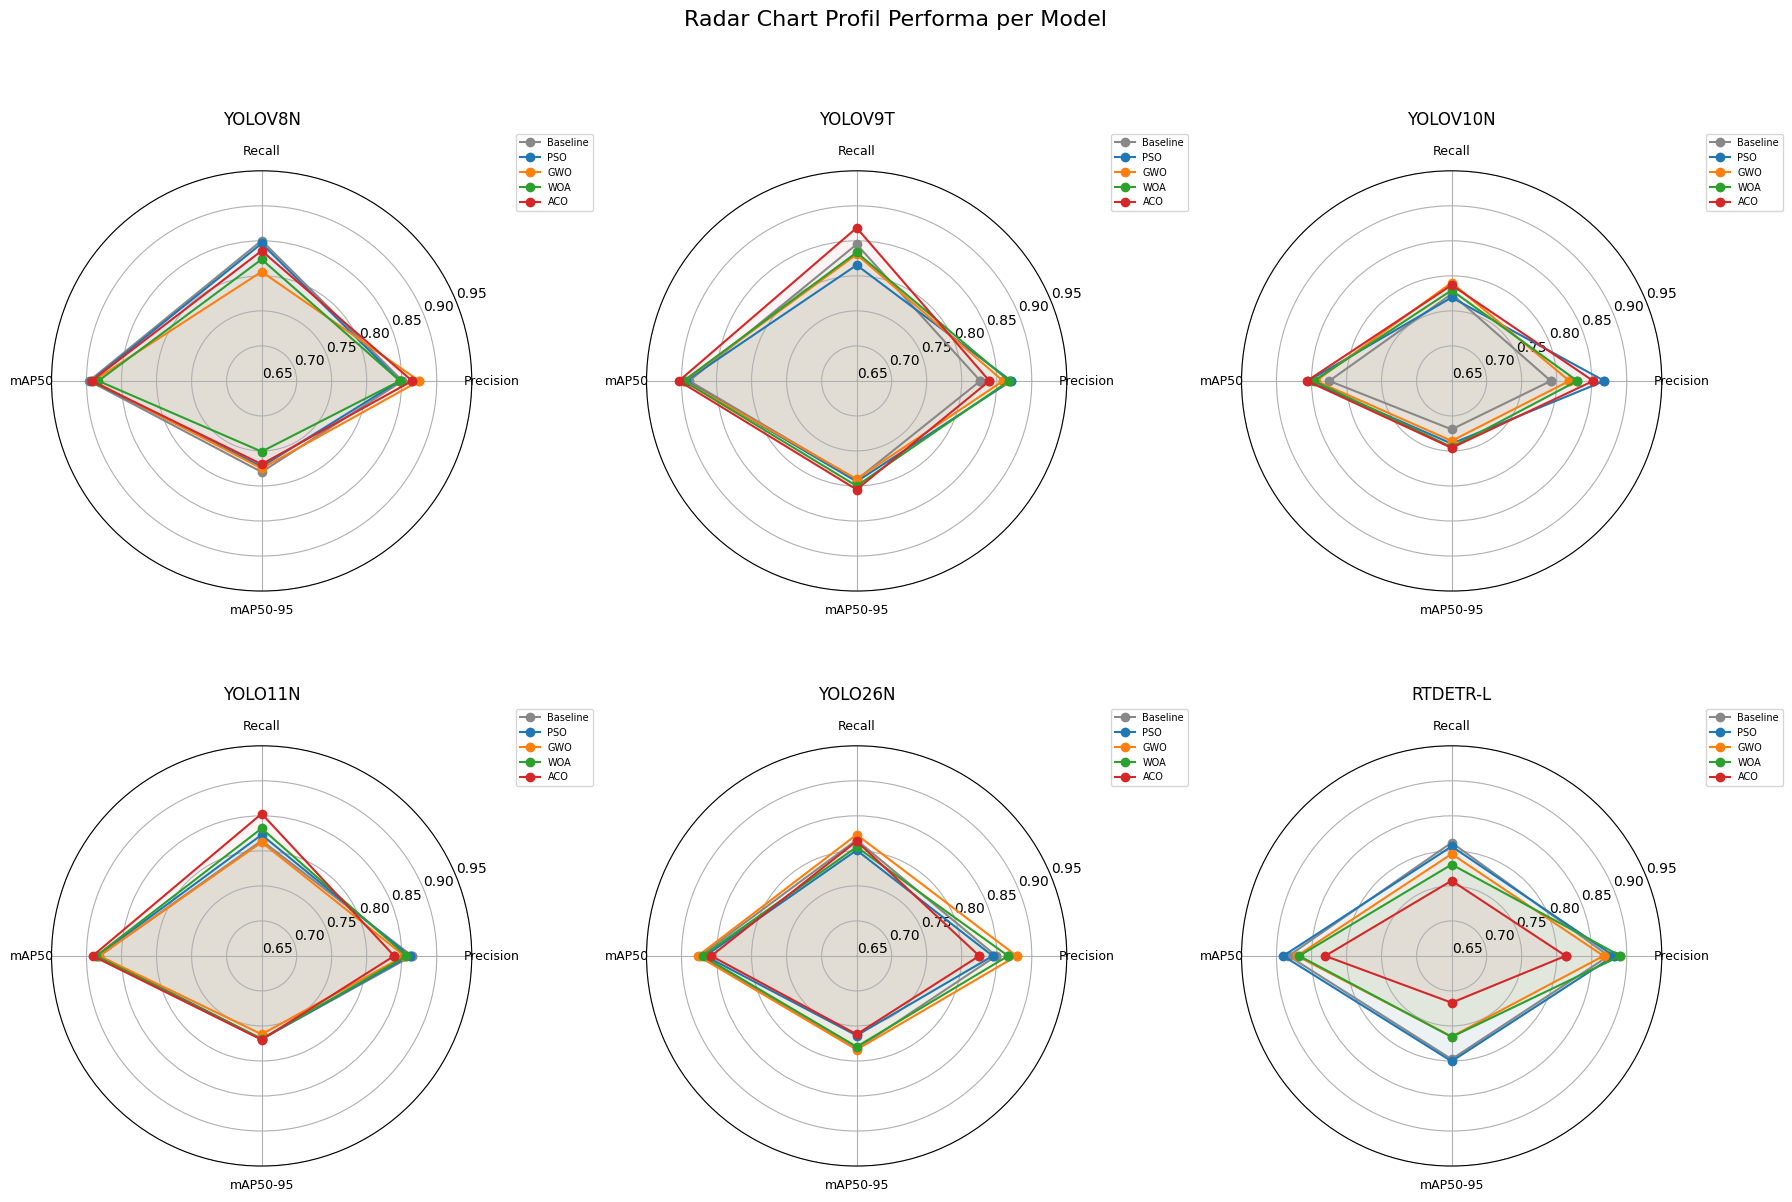

In [24]:
categories = ['Precision', 'Recall', 'mAP50', 'mAP50-95']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()
method_colors = {'Baseline': '#888888', 'PSO': '#1f77b4', 'GWO': '#ff7f0e', 'WOA': '#2ca02c', 'ACO': '#d62728'}

for i, m in enumerate(models):
    ax = axes[i]
    md_ = df_summary[df_summary['Model'] == m.upper()]
    for _, row in md_.iterrows():
        values = [row[c] for c in categories]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=1.5, label=row['Method'], color=method_colors.get(row['Method'], '#000'))
        ax.fill(angles, values, alpha=0.05, color=method_colors.get(row['Method'], '#000'))
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=9)
    ax.set_title(m.upper(), fontsize=12, pad=15)
    ax.set_ylim(0.65, 0.95)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=7)

plt.suptitle('Radar Chart Profil Performa per Model', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('radar_chart_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Scatter Plot Trade-off Precision vs Recall

Scatter plot menunjukkan trade-off antara Precision dan Recall untuk setiap kombinasi model dan optimizer.

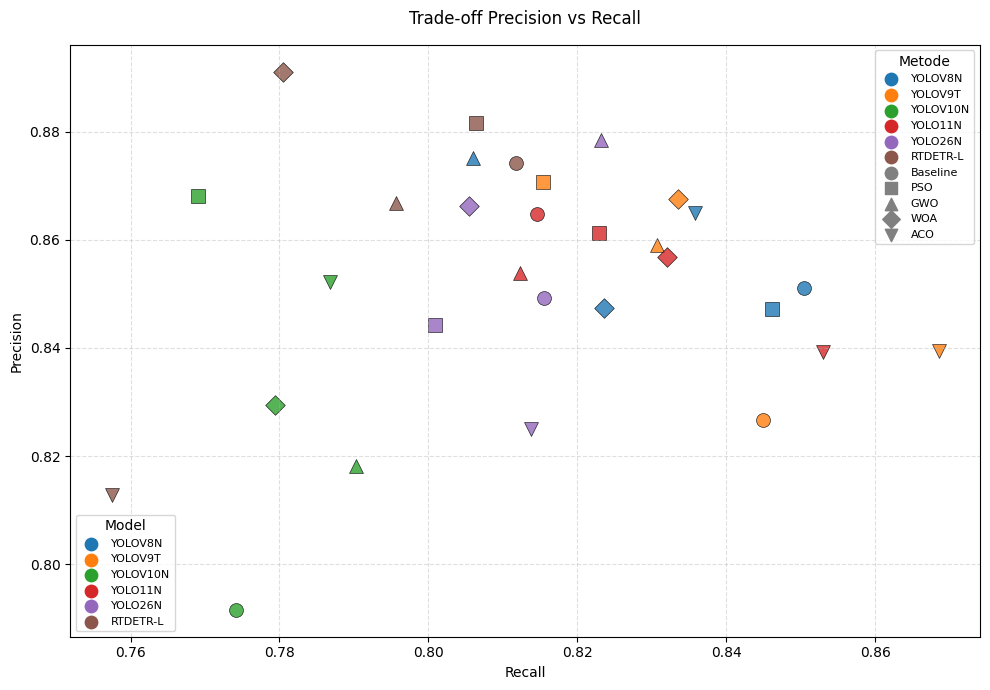

In [25]:
plt.figure(figsize=(10, 7))
markers = {'Baseline': 'o', 'PSO': 's', 'GWO': '^', 'WOA': 'D', 'ACO': 'v'}
model_colors = {m.upper(): plt.cm.tab10(i) for i, m in enumerate(models)}

for _, row in df_summary.iterrows():
    plt.scatter(row['Recall'], row['Precision'],
               marker=markers.get(row['Method'], 'o'),
               color=model_colors[row['Model']], s=100, alpha=0.8,
               edgecolors='black', linewidth=0.5)

# Legend untuk model (warna)
for m_name, color in model_colors.items():
    plt.scatter([], [], color=color, s=80, label=m_name)
leg1 = plt.legend(title='Model', loc='lower left', fontsize=8)
plt.gca().add_artist(leg1)

# Legend untuk method (marker)
for meth, mk in markers.items():
    plt.scatter([], [], marker=mk, color='gray', s=80, label=meth)
plt.legend(title='Metode', loc='upper right', fontsize=8)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Trade-off Precision vs Recall', pad=15)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('scatter_precision_recall.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Identifikasi Optimizer Terbaik per Model

In [26]:
best_rows = []
for m in models:
    md_ = df_summary[df_summary['Model'] == m.upper()]
    bl = md_[md_['Method'] == 'Baseline']['mAP50'].values[0]
    hpo = md_[md_['Method'] != 'Baseline']
    best = hpo.loc[hpo['mAP50'].idxmax()]
    d = best['mAP50'] - bl
    best_rows.append({'Model': m.upper(), 'Best_Optimizer': best['Method'],
        'Baseline_mAP50': round(bl, 4), 'Best_mAP50': round(best['mAP50'], 4),
        'Delta': round(d, 4), 'Delta_Pct': f'{(d/bl)*100:+.2f}%'})

df_best = pd.DataFrame(best_rows)
df_best.to_csv('best_optimizer_per_model.csv', index=False)
print('Disimpan ke best_optimizer_per_model.csv')
df_best

Disimpan ke best_optimizer_per_model.csv


,Model,Best_Optimizer,Baseline_mAP50,Best_mAP50,Delta,Delta_Pct
0,YOLOV8N,PSO,0.8962,0.8937,-0.0025,-0.27%
1,YOLOV9T,ACO,0.8890,0.9038,0.0148,+1.66%
2,YOLOV10N,ACO,0.8248,0.8566,0.0318,+3.85%
3,YOLO11N,ACO,0.8816,0.8914,0.0098,+1.11%
4,YOLO26N,GWO,0.8738,0.8767,0.0029,+0.33%
5,RTDETR-L,PSO,0.8830,0.8905,0.0075,+0.85%


## 12. Statistik Frekuensi Kemenangan Optimizer

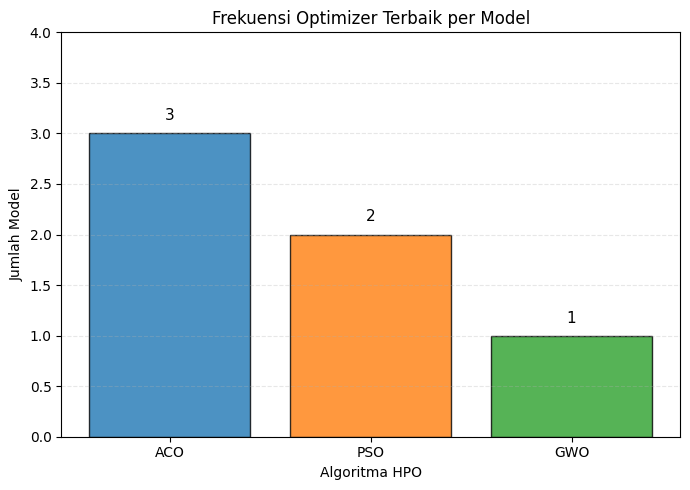

In [27]:
win_counts = df_best['Best_Optimizer'].value_counts()
plt.figure(figsize=(7, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = plt.bar(win_counts.index, win_counts.values, color=colors[:len(win_counts)], edgecolor='black', alpha=0.8)
plt.title('Frekuensi Optimizer Terbaik per Model')
plt.xlabel('Algoritma HPO')
plt.ylabel('Jumlah Model')
plt.ylim(0, max(win_counts.values) + 1)
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2., h+0.1, f'{int(h)}', ha='center', va='bottom', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('optimizer_win_count.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. Ranking Global Seluruh Kombinasi Model-Optimizer

In [28]:
df_ranking = df_summary[['Model','Method','Precision','Recall','mAP50','mAP50-95']].copy()
df_ranking = df_ranking.sort_values('mAP50', ascending=False).reset_index(drop=True)
df_ranking.index = df_ranking.index + 1
df_ranking.index.name = 'Rank'
df_ranking.to_csv('global_ranking.csv')
print('Ranking global disimpan ke global_ranking.csv')
df_rd = df_ranking.copy()
for c in ['Precision','Recall','mAP50','mAP50-95']:
    df_rd[c] = df_rd[c].map(lambda x: f'{x:.4f}')
df_rd

Ranking global disimpan ke global_ranking.csv


,Model,Method,Precision,Recall,mAP50,mAP50-95
Rank,,,,,,
1,YOLOV9T,ACO,0.8395,0.8685,0.9038,0.8050
2,YOLOV9T,WOA,0.8675,0.8335,0.8971,0.8000
3,YOLOV9T,GWO,0.8590,0.8306,0.8964,0.7901
4,YOLOV8N,Baseline,0.8510,0.8504,0.8962,0.7800
5,YOLOV9T,PSO,0.8707,0.8154,0.8938,0.7936
6,YOLOV8N,PSO,0.8473,0.8462,0.8937,0.7725
7,YOLOV8N,ACO,0.8649,0.8358,0.8929,0.7689
8,YOLO11N,ACO,0.8392,0.8530,0.8914,0.7696
9,YOLOV8N,GWO,0.8750,0.8060,0.8906,0.7750


## 14. Perbandingan Hyperparameter Terbaik Hasil HPO

Diekstrak langsung dari kolom CSV tanpa file JSON terpisah.

In [29]:
hpo_cols = ['lr0', 'lrf', 'momentum', 'weight_decay', 'mosaic', 'box']
all_params = []
for m in models:
    csv_path = os.path.join(model_dirs[m], 'final_metrics_comparison.csv')
    df_m = pd.read_csv(csv_path)
    if 'Optimizer' in df_m.columns: df_m = df_m.rename(columns={'Optimizer': 'Method'})
    for _, row in df_m.iterrows():
        if row['Method'] == 'Baseline': continue
        pr = {'Model': m.upper(), 'Method': row['Method']}
        for c in hpo_cols: pr[c] = round(row[c], 6) if c in row else np.nan
        all_params.append(pr)
df_params = pd.DataFrame(all_params)
df_params.to_csv('all_models_best_hyperparameters.csv', index=False)
print('Disimpan ke all_models_best_hyperparameters.csv')
df_params

Disimpan ke all_models_best_hyperparameters.csv


,Model,Method,lr0,lrf,momentum,weight_decay,mosaic,box
0,YOLOV8N,PSO,0.017141,0.005000,0.874706,0.004782,0.827316,5.845232
1,YOLOV8N,GWO,0.025000,0.034350,0.980000,0.004950,1.000000,6.600953
2,YOLOV8N,WOA,0.015304,0.024853,0.980000,0.007148,1.000000,10.000000
3,YOLOV8N,ACO,0.019965,0.030939,0.875786,0.006897,0.784736,5.935554
4,YOLOV9T,PSO,0.012168,0.022708,0.976400,0.004158,0.700276,8.253073
5,YOLOV9T,GWO,0.010302,0.019647,0.850000,0.006015,0.821229,5.000000
6,YOLOV9T,WOA,0.020893,0.028054,0.941635,0.008778,0.871208,5.625018
7,YOLOV9T,ACO,0.016064,0.027705,0.960167,0.007523,0.718763,5.752039
8,YOLOV10N,PSO,0.011695,0.045794,0.917004,0.005063,0.867366,5.341147
9,YOLOV10N,GWO,0.008937,0.026615,0.980000,0.003228,0.950787,7.134702


## 15. Distribusi Hyperparameter per Optimizer

Boxplot menunjukkan sebaran nilai hyperparameter yang dipilih oleh masing-masing algoritma HPO di seluruh model.

/tmp/ipykernel_19849/4121947152.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Method', y=col, data=df_params, ax=ax, palette='Set2')
/tmp/ipykernel_19849/4121947152.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Method', y=col, data=df_params, ax=ax, palette='Set2')
/tmp/ipykernel_19849/4121947152.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Method', y=col, data=df_params, ax=ax, palette='Set2')
/tmp/ipykernel_19849/4121947152.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will b

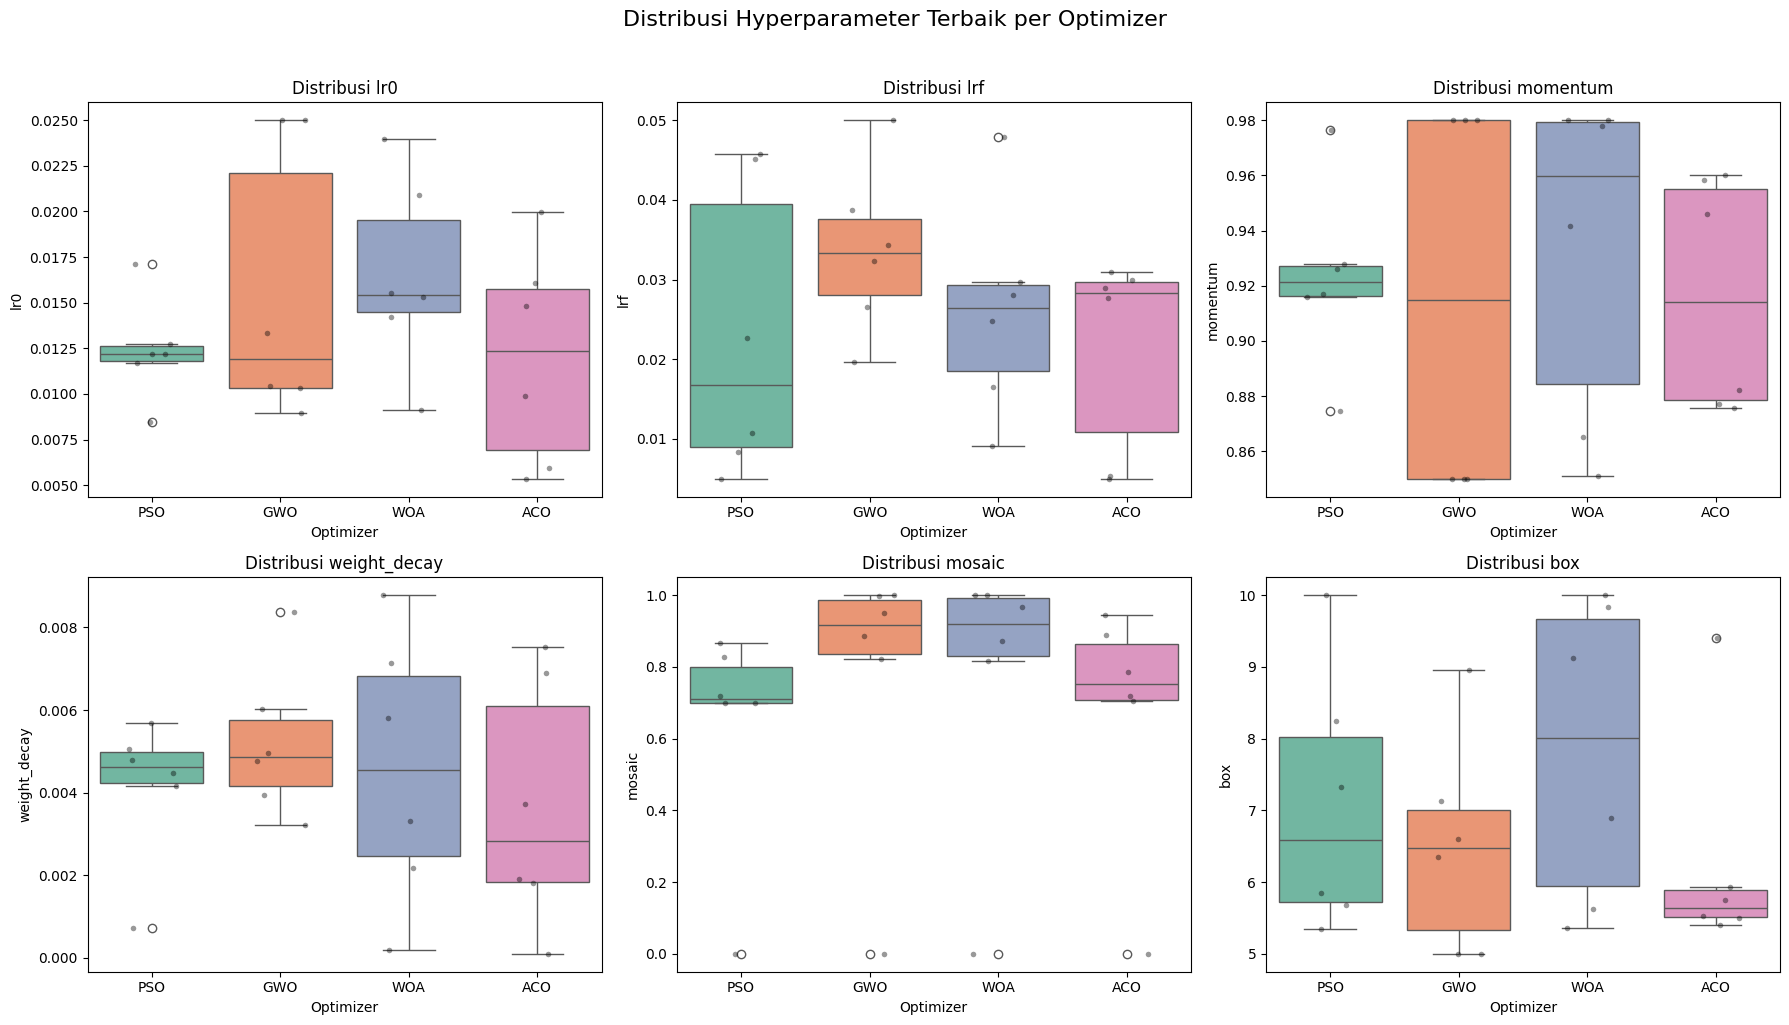

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(), hpo_cols):
    sns.boxplot(x='Method', y=col, data=df_params, ax=ax, palette='Set2')
    sns.stripplot(x='Method', y=col, data=df_params, ax=ax, color='black', alpha=0.4, jitter=0.2, size=4)
    ax.set_title(f'Distribusi {col}', fontsize=12)
    ax.set_xlabel('Optimizer')
    ax.set_ylabel(col)
plt.suptitle('Distribusi Hyperparameter Terbaik per Optimizer', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('hyperparameter_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 16. Export Tabel ke Format Markdown

Tabel pivot mAP50 dan mAP50-95 siap disalin ke naskah Tugas Akhir.

In [31]:
pivot_map50 = df_summary.pivot(index='Model', columns='Method', values='mAP50')
pivot_map50 = pivot_map50.reindex([m.upper() for m in models])
pivot_map50 = pivot_map50[['Baseline','PSO','GWO','WOA','ACO']]

print('=== TABEL MARKDOWN (mAP50) ===\n')
print(pivot_map50.round(4).to_markdown())

pivot_map5095 = df_summary.pivot(index='Model', columns='Method', values='mAP50-95')
pivot_map5095 = pivot_map5095.reindex([m.upper() for m in models])
pivot_map5095 = pivot_map5095[['Baseline','PSO','GWO','WOA','ACO']]

print('\n\n=== TABEL MARKDOWN (mAP50-95) ===\n')
print(pivot_map5095.round(4).to_markdown())

=== TABEL MARKDOWN (mAP50) ===

| Model    |   Baseline |    PSO |    GWO |    WOA |    ACO |
|:---------|-----------:|-------:|-------:|-------:|-------:|
| YOLOV8N  |     0.8962 | 0.8937 | 0.8906 | 0.8831 | 0.8929 |
| YOLOV9T  |     0.889  | 0.8938 | 0.8964 | 0.8971 | 0.9038 |
| YOLOV10N |     0.8248 | 0.8546 | 0.8437 | 0.8468 | 0.8566 |
| YOLO11N  |     0.8816 | 0.8848 | 0.8818 | 0.8863 | 0.8914 |
| YOLO26N  |     0.8738 | 0.8661 | 0.8767 | 0.8699 | 0.8576 |
| RTDETR-L |     0.883  | 0.8905 | 0.871  | 0.8676 | 0.8305 |


=== TABEL MARKDOWN (mAP50-95) ===

| Model    |   Baseline |    PSO |    GWO |    WOA |    ACO |
|:---------|-----------:|-------:|-------:|-------:|-------:|
| YOLOV8N  |     0.78   | 0.7725 | 0.775  | 0.7509 | 0.7689 |
| YOLOV9T  |     0.7912 | 0.7936 | 0.7901 | 0.8    | 0.805  |
| YOLOV10N |     0.7192 | 0.7396 | 0.7356 | 0.7446 | 0.7456 |
| YOLO11N  |     0.7688 | 0.7687 | 0.7618 | 0.7687 | 0.7696 |
| YOLO26N  |     0.7828 | 0.7636 | 0.7838 | 0.7796 | 0.7619 |
|

## 17. Ringkasan Temuan

In [32]:
print('='*60)
print('RINGKASAN TEMUAN EKSPERIMEN')
print('='*60)

best_overall = df_summary.loc[df_summary['mAP50'].idxmax()]
print(f'\nKombinasi Terbaik Keseluruhan:')
print(f'  Model    : {best_overall["Model"]}')
print(f'  Metode   : {best_overall["Method"]}')
print(f'  mAP50    : {best_overall["mAP50"]:.4f}')
print(f'  mAP50-95 : {best_overall["mAP50-95"]:.4f}')

print(f'\nOptimizer Terbaik per Model:')
for _, row in df_best.iterrows():
    print(f'  {row["Model"]:12s} -> {row["Best_Optimizer"]:4s} (mAP50: {row["Best_mAP50"]:.4f}, delta: {row["Delta_Pct"]})')

avg_delta = pd.DataFrame(delta_rows).groupby('Method')['Delta'].mean()
print(f'\nRata-rata Peningkatan mAP50 per Optimizer:')
for method, delta in avg_delta.items():
    print(f'  {method:4s}: {delta:+.4f}')
print('\n' + '='*60)

RINGKASAN TEMUAN EKSPERIMEN

Kombinasi Terbaik Keseluruhan:
  Model    : YOLOV9T
  Metode   : ACO
  mAP50    : 0.9038
  mAP50-95 : 0.8050

Optimizer Terbaik per Model:
  YOLOV8N      -> PSO  (mAP50: 0.8937, delta: -0.27%)
  YOLOV9T      -> ACO  (mAP50: 0.9038, delta: +1.66%)
  YOLOV10N     -> ACO  (mAP50: 0.8566, delta: +3.85%)
  YOLO11N      -> ACO  (mAP50: 0.8914, delta: +1.11%)
  YOLO26N      -> GWO  (mAP50: 0.8767, delta: +0.33%)
  RTDETR-L     -> PSO  (mAP50: 0.8905, delta: +0.85%)

Rata-rata Peningkatan mAP50 per Optimizer:
  ACO : -0.0026
  GWO : +0.0020
  PSO : +0.0059
  WOA : +0.0004

